# Evaluación 2 — Redes neuronales y transformada de Fourier

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
**ID personalizado: 1835**

Este notebook resuelve las tres partes de la evaluación:
1. **Capa Fourier**: construcción, verificación y energía del dataset.
2. **Entrenamiento y reconstrucción**: red con dos inicializaciones (Fourier y aleatoria) en los tres regímenes.
3. **Compresión**: cuántos coeficientes Fourier capturan el 85 % de la energía.


---
## 0. Imports y carga de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax
import jax.numpy as jnp
from jax import jit
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(1835)

# Estilo de figuras consistente
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
REGIME_COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}
REGIME_NAMES  = {0: 'Régimen 0 — sin dispersión', 1: 'Régimen 1 — dispersión media', 2: 'Régimen 2 — dispersión fuerte'}
print('JAX version:', jax.__version__)

JAX version: 0.7.2


In [2]:
# ---------- Carga de datos ----------
datos = np.load('datos_1835.npz', allow_pickle=True)
X = datos['X'].astype(np.float32)   # (24, 256) — señales
y = datos['y'].astype(int)           # (24,)     — etiqueta de régimen
t = datos['t'].astype(np.float32)   # (256,)    — eje temporal en [0, 1)

T  = X.shape[1]   # 256 muestras por señal
K  = 15           # frecuencias de la capa Fourier (enunciado)

print(f'Dataset: {X.shape[0]} señales × {T} muestras')
print(f'Regímenes: {np.unique(y)}  — {dict(zip(*np.unique(y, return_counts=True)))}')
print(f't en [{t.min():.4f}, {t.max():.4f}], paso Δt = {t[1]-t[0]:.6f}')

Dataset: 24 señales × 256 muestras
Regímenes: [0 1 2]  — {np.int64(0): np.int64(8), np.int64(1): np.int64(8), np.int64(2): np.int64(8)}
t en [0.0000, 0.9961], paso Δt = 0.003906


### Visualización exploratoria del dataset

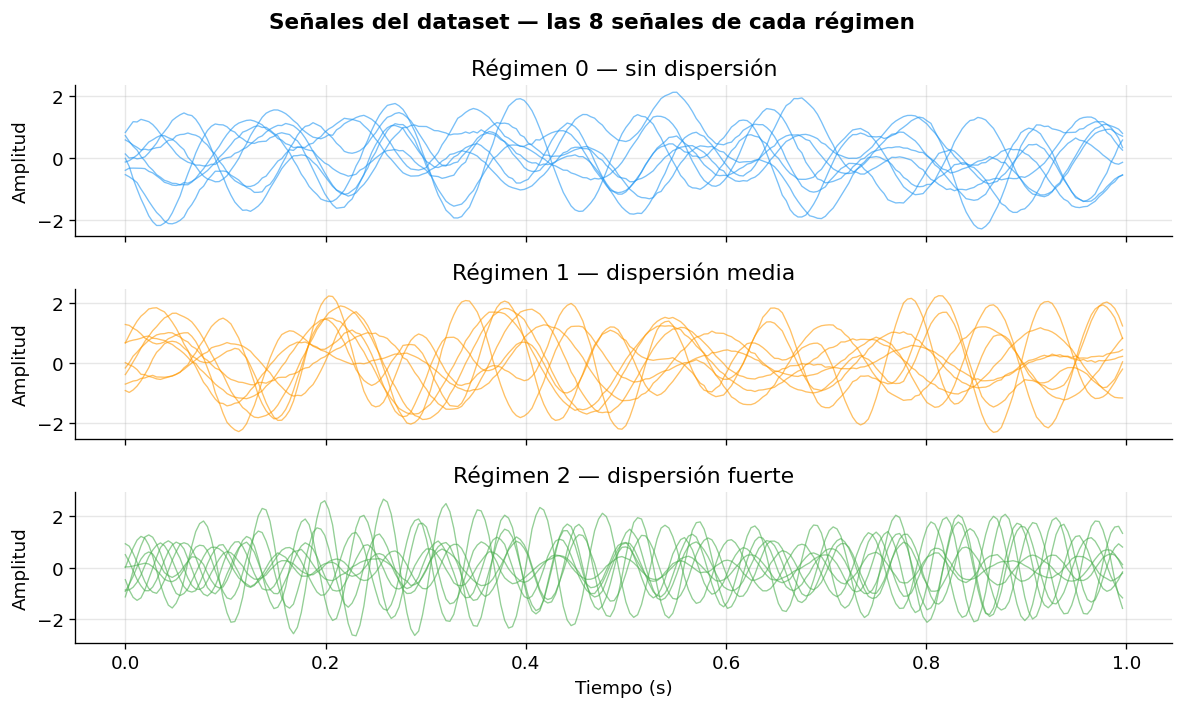

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for r, ax in zip([0, 1, 2], axes):
    idx = np.where(y == r)[0]
    for i in idx:
        ax.plot(t, X[i], color=REGIME_COLORS[r], alpha=0.6, lw=0.8)
    ax.set_ylabel('Amplitud')
    ax.set_title(REGIME_NAMES[r])

axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señales del dataset — las 8 señales de cada régimen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_00_dataset.png', bbox_inches='tight')
plt.show()